Image shape: (282, 381)


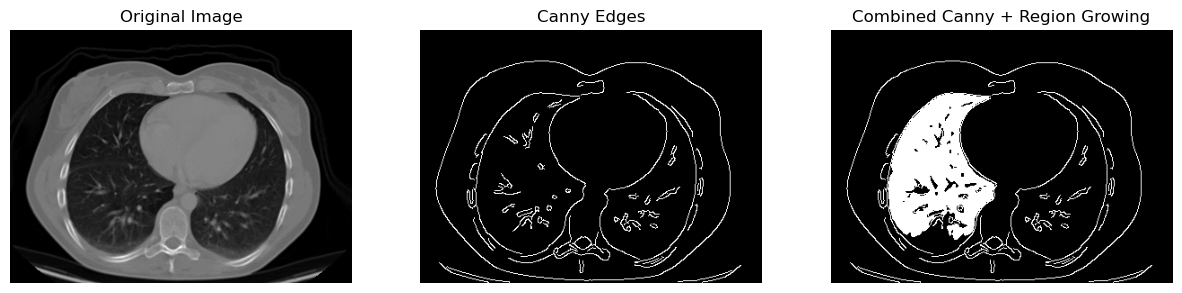

Canny Edge Detection and Region Growing Segmentation completed. Check the output image.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function for region growing segmentation
def region_growing(image, seed_point, threshold):
    # Create an empty mask to keep track of the segmented region
    mask = np.zeros_like(image, dtype=np.uint8)

    # Initialize the list of pixels to process
    to_process = [seed_point]
    region_mean = image[seed_point]

    while to_process:
        # Pop the last pixel from the list
        current_pixel = to_process.pop()

        # If the pixel is already in the mask, skip it
        if mask[current_pixel]:
            continue

        # Add the pixel to the mask
        mask[current_pixel] = 255
        
        # Check neighboring pixels (4-connectivity)
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            neighbor = (current_pixel[0] + dx, current_pixel[1] + dy)
            if (0 <= neighbor[0] < image.shape[0] and
                0 <= neighbor[1] < image.shape[1] and
                not mask[neighbor] and
                abs(int(image[neighbor]) - int(region_mean)) < threshold):
                
                to_process.append(neighbor)

        # Update the region mean
        region_mean = np.mean(image[mask == 255])

    return mask

# Load the CT scan image (grayscale)
image_path = '000108 (3).png'  # Update with your image path
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded
if image is None:
    print("Error: Image not found. Please check the path.")
    exit()

# Print image shape to confirm loading
print("Image shape:", image.shape)

# Preprocess the image: Apply Gaussian blur to reduce noise
blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

# Perform Canny edge detection
edges = cv2.Canny(blurred_image, threshold1=50, threshold2=150)

# Set seed point and threshold for region growing
seed_point = (100, 100)  # Adjust this based on your image
threshold = 15  # Adjust based on your needs

# Perform region growing segmentation
segmented_mask = region_growing(blurred_image, seed_point, threshold)

# Combine the two results for display:
# Use bitwise OR to combine the Canny edges and the region growing mask
combined_result = cv2.bitwise_or(edges, segmented_mask)

# Display the results side by side in a single plot
plt.figure(figsize=(15, 6))

# Original image
plt.subplot(1, 3, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.axis('off')

# Canny Edge Detection Output
plt.subplot(1, 3, 2)
plt.title('Canny Edges')
plt.imshow(edges, cmap='gray')
plt.axis('off')

# Combined Result (Canny + Region Growing)
plt.subplot(1, 3, 3)
plt.title('Combined Canny + Region Growing')
plt.imshow(combined_result, cmap='gray')
plt.axis('off')

plt.show()

# Save the combined result (optional)
output_path = 'combined_result.jpg'  # Path to save the combined image
cv2.imwrite(output_path, combined_result)

print("Canny Edge Detection and Region Growing Segmentation completed. Check the output image.")
